# Phase 6 — Generation & Faithfulness: does any of the retrieval work change the answer?

**RAG Pipeline Optimizer · Session 6 of 7 · 2026-06-06**

Phases 1–5 spent five sessions moving a single retrieval number — nDCG@10 — with chunking,
encoders, indexes, re-rankers and query rewrites. Every one of those gains is an *assumption*:
that a better-ranked context list produces a better **answer**. Almost no RAG tutorial ever
checks that assumption. Phase 6 closes the loop and asks the only question a user cares about:

> **Does the retrieved context actually reach the answer — and does better retrieval make the
> generated answer measurably better, or does the LLM route around it?**

We measure four RAGAS-style signals on a real generator (Claude Haiku over FiQA financial Q&A):
**faithfulness** (are the answer's claims entailed by the context it was given?), **answer
relevancy**, **answer correctness vs. the gold passage**, and **citation grounding**. We sweep
context *quality* from oracle → strong (E5) → HyDE×N → adversarial → none, hunting the
counter-intuitive: where does the faithfulness/correctness curve flatten, and can wrong-but-plausible
context *manufacture* confident hallucinations?

Then two carry-over questions the prior phases opened:
- **Exp E (the backward link from Phase 4/5):** HyDE×N lifts Recall@100 — does feeding *those*
  candidates to a cross-encoder finally let the re-ranker help, where on the naive candidates it hurt?
- **RAGAS context precision/recall** computed *exactly* from BEIR qrels across all 3 corpora — the
  no-LLM retrieval-quality axis the generation results are plotted against.

**Primary metric for retrieval:** nDCG@10 (every prior phase). **Primary metrics for generation:**
faithfulness and answer-correctness. Generator and judge are both Claude; the judge model is held
**fixed (Haiku)** while the generator varies, so generator differences aren't confounded by judge drift.

### Research & references
1. **Es, James, Espinosa-Anke, Schockaert (2023) — "RAGAS: Automated Evaluation of RAG".** Defines
   faithfulness (claim-level entailment against retrieved context), answer relevancy (regenerate
   questions from the answer, embed, compare to the original), context precision & context recall.
   We re-implement these with a Claude judge + the E5 encoder rather than the OpenAI-bound `ragas` pkg.
2. **Gao et al. (2022) — HyDE.** Source of the HyDE×N candidates reused from Phase 5 for Exp E.
3. **Khattab & Zaharia / cross-encoder re-ranking (Phase 4 in-repo).** The MiniLM-L6 cross-encoder
   that hurt on naive candidates; Exp E re-tests it on the higher-recall HyDE×N candidate set.


In [1]:
import os, time, json, glob, subprocess, re as _re, hashlib
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import torch; torch.set_num_threads(os.cpu_count())
np.set_printoptions(suppress=True)

EMB_DIR = "../data/processed/emb_cache"; RES = "../results"
CACHE = f"{RES}/phase6_cache"; LLM = f"{RES}/phase6_llm_cache"
P5LLM = f"{RES}/phase5_llm_cache"
os.makedirs(CACHE, exist_ok=True); os.makedirs(LLM, exist_ok=True)

# --- metric harness, copied VERBATIM from Phases 1-5 for cross-phase parity ---
def dcg(gains, mode="exp"):
    g = np.asarray(gains, float)
    if g.size == 0: return 0.0
    num = (2**g - 1) if mode == "exp" else g
    return float(np.sum(num / np.log2(np.arange(2, g.size + 2))))

def evaluate(run, qrels, ks=(1,3,5,10,20,100), mode="exp"):
    out = {f"{m}@{k}": [] for k in ks for m in ("ndcg","recall","mrr")}
    for qid, gold in qrels.items():
        if not gold: continue
        seen, ranked = set(), []
        for d in run.get(qid, []):
            if d not in seen: seen.add(d); ranked.append(d)
        n_rel = sum(1 for g in gold.values() if g > 0)
        gains = [gold.get(d, 0) for d in ranked]; ideal = sorted(gold.values(), reverse=True)
        for k in ks:
            idcg = dcg(ideal[:k], mode)
            out[f"ndcg@{k}"].append(dcg(gains[:k], mode)/idcg if idcg > 0 else 0.0)
            out[f"recall@{k}"].append(sum(1 for g in gains[:k] if g > 0)/n_rel if n_rel else 0.0)
            rr = 0.0
            for r, g in enumerate(gains[:k], 1):
                if g > 0: rr = 1.0/r; break
            out[f"mrr@{k}"].append(rr)
    return {m: float(np.mean(v)) if v else 0.0 for m, v in out.items()}

def per_query_ndcg(run, qrels, k=10, mode="exp"):
    res = {}
    for qid, gold in qrels.items():
        if not gold: continue
        seen, ranked = set(), []
        for d in run.get(qid, []):
            if d not in seen: seen.add(d); ranked.append(d)
        gains = [gold.get(d, 0) for d in ranked]; ideal = sorted(gold.values(), reverse=True)
        idcg = dcg(ideal[:k], mode); res[qid] = dcg(gains[:k], mode)/idcg if idcg > 0 else 0.0
    return res

def topk_idx(D, v, k):
    sims = D @ v; k = min(k, D.shape[0])
    part = np.argpartition(-sims, k-1)[:k]
    return part[np.argsort(-sims[part])], sims

print("harness ready | torch", torch.__version__, "| threads", torch.get_num_threads())

harness ready | torch 2.12.0 | threads 10


## Setup — load the 3 BEIR corpora and reuse every cached E5 embedding

Nothing is re-embedded on the document side: the E5-base-v2 corpus vectors are the exact
files Phases 2–5 produced, so all retrieval numbers are directly comparable across phases.

In [2]:
from datasets import load_dataset
import datasets as _ds; _ds.disable_progress_bars()

def load_beir(name, qrels_split="test"):
    corpus = load_dataset(f"BeIR/{name}", "corpus", split="corpus")
    queries = load_dataset(f"BeIR/{name}", "queries", split="queries")
    qrels_t = load_dataset(f"BeIR/{name}-qrels", split=qrels_split)
    docs = {str(r["_id"]): ((r["title"]+". "+r["text"]).strip() if r["title"] else r["text"]) for r in corpus}
    qtext = {str(r["_id"]): r["text"] for r in queries}
    qrels = defaultdict(dict)
    for r in qrels_t: qrels[str(r["query-id"])][str(r["corpus-id"])] = int(r["score"])
    qtext = {q: t for q, t in qtext.items() if q in qrels}
    return docs, qtext, dict(qrels)

DOMAIN = {"scifact":"scientific claim verification", "nfcorpus":"medical / health information",
          "fiqa":"personal finance and investing"}
CORP = {}
for name in ["scifact","nfcorpus","fiqa"]:
    docs, queries, qrels = load_beir(name)
    doc_ids, q_ids = list(docs), list(queries)
    D = np.load(f"{EMB_DIR}/E5-base-v2__{name}_docs.npy").astype("float32")
    Q = np.load(f"{EMB_DIR}/E5-base-v2__{name}_q.npy").astype("float32")
    assert D.shape[0] == len(doc_ids) and Q.shape[0] == len(q_ids), (name, D.shape, Q.shape)
    CORP[name] = dict(name=name, docs=docs, queries=queries, qrels=qrels, doc_ids=doc_ids,
                      q_ids=q_ids, D=D, Q=Q, didx={d:i for i,d in enumerate(doc_ids)})
    run = {qid: [doc_ids[j] for j in topk_idx(D, Q[i], 100)[0]] for i, qid in enumerate(q_ids)}
    CORP[name]["naive_run"] = run
    CORP[name]["naive_m"] = evaluate(run, qrels)
    m = CORP[name]["naive_m"]
    print(f"{name:9s} docs={len(doc_ids):6d} q={len(q_ids):4d} | naive nDCG@10={m['ndcg@10']:.4f} "
          f"R@10={m['recall@10']:.4f} R@100={m['recall@100']:.4f}")

/Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/RAG-Pipeline-Optimizer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scifact   docs=  5183 q= 300 | naive nDCG@10=0.7274 R@10=0.8507 R@100=0.9627


nfcorpus  docs=  3633 q= 323 | naive nDCG@10=0.3529 R@10=0.1706 R@100=0.3196


fiqa      docs= 57638 q= 648 | naive nDCG@10=0.3987 R@10=0.4705 R@100=0.7320


## Reconstruct the Phase-5 retrievers on the cached samples

Three retrievers define the *retrieval-quality axis* for everything below:
- **naive** — raw E5-base-v2 query (the Phase-2 champion)
- **HyDE×N** — mean(query, hyde₁, hyde₂) re-embedded; the only LLM query trick that helped all 3 corpora in Phase 5
- **PRF** — free Rocchio pseudo-relevance feedback (no LLM), best (k,β) from the Phase-5 sweep

HyDE hypotheticals and their E5 embeddings are loaded from the Phase-5 cache (`gen_haiku.json`,
`gen_emb.npz`) — zero new generation needed to rebuild them.

In [3]:
# ---- load Phase-5 HyDE generations + their cached embeddings ----
GEN5 = json.load(open(f"{P5LLM}/gen_haiku.json"))
def gkey(ds, qid): return f"{ds}::{qid}"
_z = np.load(f"{P5LLM}/gen_emb.npz", allow_pickle=True)
HEMB = {k: _z[k] for k in _z.files if k != "__keys__"}
def _h(t): return hashlib.md5(t.encode()).hexdigest()
def gv(t): return HEMB[_h(t)]

# ---- stratified samples (reuse Phase-5 cached qid lists) ----
SAMP = {n: json.load(open(f"{P5LLM}/sample_{n}.json")) for n in CORP}
for n in CORP: print(f"{n:9s} sample={len(SAMP[n])} (HyDE-parsed available for all)")

def rank_ids(c, v, k=100):
    idx, _ = topk_idx(c["D"], v, k); return [c["doc_ids"][j] for j in idx]

# ---- best PRF config per dataset (from Phase-5 metrics.json) ----
_p5 = json.load(open(f"{RES}/metrics.json")).get("phase5", {})
PRF_BEST = {n: _p5.get("prf_best", {}).get(n, {"k_fb":3, "beta":0.5}) for n in CORP}

def build_axis_runs(c, qids, k=100):
    # naive / hydeN / prf top-k runs for a list of qids
    out = {t: {} for t in ["naive","hydeN","prf"]}
    kf = int(PRF_BEST[c["name"]]["k_fb"]); bt = float(PRF_BEST[c["name"]]["beta"])
    for qid in qids:
        i = c["q_ids"].index(qid); qv = c["Q"][i]
        out["naive"][qid] = rank_ids(c, qv, k)
        sims = c["D"] @ qv; top = np.argpartition(-sims, kf-1)[:kf]
        ev = qv + bt*c["D"][top].mean(0); ev /= np.linalg.norm(ev)
        out["prf"][qid] = rank_ids(c, ev, k)
        p = GEN5.get(gkey(c["name"], qid), {}).get("parsed")
        if p and p.get("hyde"):
            vecs = [qv] + [gv(x) for x in p["hyde"] if _h(x) in HEMB]
            mv = np.mean(vecs, 0); mv /= np.linalg.norm(mv)
            out["hydeN"][qid] = rank_ids(c, mv, k)
        else:
            out["hydeN"][qid] = out["naive"][qid]
    return out

AXIS = {n: build_axis_runs(CORP[n], SAMP[n], 100) for n in CORP}
for n in CORP:
    sub = {q: CORP[n]["qrels"][q] for q in SAMP[n]}
    line = " | ".join(f"{t} nDCG@10={evaluate(AXIS[n][t], sub)['ndcg@10']:.3f}" for t in ["naive","hydeN","prf"])
    print(f"{n:9s} {line}")

scifact   sample=40 (HyDE-parsed available for all)
nfcorpus  sample=40 (HyDE-parsed available for all)
fiqa      sample=40 (HyDE-parsed available for all)


scifact   naive nDCG@10=0.428 | hydeN nDCG@10=0.544 | prf nDCG@10=0.424
nfcorpus  naive nDCG@10=0.362 | hydeN nDCG@10=0.393 | prf nDCG@10=0.365
fiqa      naive nDCG@10=0.338 | hydeN nDCG@10=0.378 | prf nDCG@10=0.339


## Experiment A — RAGAS context precision & recall, computed *exactly* from qrels (no LLM)

RAGAS's two **retrieval** metrics don't need a judge when you have relevance labels:

- **Context precision@k** = rank-weighted average precision over the retrieved list — rewards putting
  relevant chunks *first* (the order the LLM reads them in). `CP@k = Σ_{i≤k}[ Prec@i · rel_i ] / Σ rel_i`.
- **Context recall@k** = fraction of all judged-relevant docs that made it into the top-k context window.

This is the clean, exact version of the retrieval-quality axis. The generation experiments below
ask whether moving these numbers moves the *answer*.

In [4]:
def context_precision_at_k(run, qrels, k=5):
    vals = []
    for qid, gold in qrels.items():
        rel = {d for d, g in gold.items() if g > 0}
        if not rel: continue
        ranked = run.get(qid, [])[:k]
        hits = 0; ap = 0.0
        for i, d in enumerate(ranked, 1):
            if d in rel:
                hits += 1; ap += hits / i
        vals.append(ap / min(len(rel), k))   # normalise by attainable hits in window
    return float(np.mean(vals)) if vals else 0.0

def context_recall_at_k(run, qrels, k=5):
    vals = []
    for qid, gold in qrels.items():
        rel = {d for d, g in gold.items() if g > 0}
        if not rel: continue
        ranked = set(run.get(qid, [])[:k])
        vals.append(len(rel & ranked) / len(rel))
    return float(np.mean(vals)) if vals else 0.0

rowsA = []
for n in CORP:
    sub = {q: CORP[n]["qrels"][q] for q in SAMP[n]}
    for t in ["naive","hydeN","prf"]:
        run = AXIS[n][t]
        rowsA.append(dict(dataset=n, retriever=t,
                          ctx_prec5=context_precision_at_k(run, sub, 5),
                          ctx_rec5=context_recall_at_k(run, sub, 5),
                          ctx_rec10=context_recall_at_k(run, sub, 10),
                          ndcg10=evaluate(run, sub)["ndcg@10"]))
dfA = pd.DataFrame(rowsA)
dfA.to_csv(f"{RES}/phase6_context_pr.csv", index=False)
for n in CORP:
    print(f"--- {n} (n={len(SAMP[n])}) ---")
    print(dfA[dfA.dataset==n].set_index("retriever")[["ndcg10","ctx_prec5","ctx_rec5","ctx_rec10"]].round(4).to_string())
    print()

--- scifact (n=40) ---
           ndcg10  ctx_prec5  ctx_rec5  ctx_rec10
retriever                                        
naive      0.4279     0.3244    0.4912     0.6525
hydeN      0.5436     0.4540    0.6600     0.7450
prf        0.4235     0.3425    0.5525     0.6275

--- nfcorpus (n=40) ---
           ndcg10  ctx_prec5  ctx_rec5  ctx_rec10
retriever                                        
naive      0.3624     0.3042    0.1635     0.2058
hydeN      0.3929     0.3311    0.1861     0.2213
prf        0.3651     0.3182    0.1701     0.2035

--- fiqa (n=40) ---
           ndcg10  ctx_prec5  ctx_rec5  ctx_rec10
retriever                                        
naive      0.3377     0.2345    0.3181     0.4172
hydeN      0.3779     0.2748    0.3941     0.4584
prf        0.3385     0.2368    0.3050     0.4165



## Experiment E — the backward link: does HyDE×N's recall finally make a cross-encoder pay?

Phase 4's headline: every cross-encoder re-ranker **hurt** nDCG@10, because it could only reorder the
candidate set the first stage handed it, and on the strong E5 first stage that set was already
well-ordered. Phase 5 showed HyDE×N is the one query trick that lifts **Recall@100** — i.e. it puts
*more* relevant docs into the candidate pool. So the open question this phase inherits:

> Re-rank the **HyDE×N top-100** instead of the naive top-100. Does the extra recall give the
> cross-encoder the room it lacked — does CE(HyDE×N) finally beat raw E5?

We score with the MiniLM-L6 cross-encoder (Phase 4's least-harmful, 22M params) on the cached samples.

In [5]:
from sentence_transformers import CrossEncoder
CE = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device="cpu", max_length=512)

def ce_rerank(c, base_run, qids, depth=100):
    out = {}
    for qid in qids:
        cand = base_run[qid][:depth]
        pairs = [(c["queries"][qid], c["docs"][d][:1200]) for d in cand]
        if not pairs: out[qid] = cand; continue
        scores = CE.predict(pairs, batch_size=64, show_progress_bar=False)
        order = np.argsort(-np.asarray(scores))
        out[qid] = [cand[i] for i in order]
    return out

rowsE = []
t0 = time.time()
for n in CORP:
    c = CORP[n]; qids = SAMP[n]; sub = {q: c["qrels"][q] for q in qids}
    base_naive = evaluate(AXIS[n]["naive"], sub); base_hyde = evaluate(AXIS[n]["hydeN"], sub)
    ce_naive = evaluate(ce_rerank(c, AXIS[n]["naive"], qids), sub)
    ce_hyde  = evaluate(ce_rerank(c, AXIS[n]["hydeN"], qids), sub)
    for label, m, ref in [("E5 naive (raw)", base_naive, None),
                          ("HyDE×N (raw)", base_hyde, base_naive),
                          ("CE(naive top100)", ce_naive, base_naive),
                          ("CE(HyDE×N top100)", ce_hyde, base_naive)]:
        rowsE.append(dict(dataset=n, pipeline=label, ndcg10=m["ndcg@10"], r10=m["recall@10"],
                          r100=m["recall@100"], mrr10=m["mrr@10"],
                          d_vs_naive=m["ndcg@10"] - base_naive["ndcg@10"]))
    print(f"{n:9s} done ({time.time()-t0:.0f}s)", flush=True)
dfE = pd.DataFrame(rowsE)
dfE.to_csv(f"{RES}/phase6_backward_link.csv", index=False)
for n in CORP:
    print(f"\n--- {n} ---")
    print(dfE[dfE.dataset==n].set_index("pipeline")[["ndcg10","r10","r100","d_vs_naive"]].round(4).to_string())

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1568.35it/s]

scifact   done (372s)


nfcorpus  done (675s)


fiqa      done (907s)



--- scifact ---
                   ndcg10     r10  r100  d_vs_naive
pipeline                                           
E5 naive (raw)     0.4279  0.6525  0.85      0.0000
HyDE×N (raw)       0.5436  0.7450  0.90      0.1157
CE(naive top100)   0.4533  0.5850  0.85      0.0254
CE(HyDE×N top100)  0.4714  0.6350  0.90      0.0435

--- nfcorpus ---
                   ndcg10     r10    r100  d_vs_naive
pipeline                                             
E5 naive (raw)     0.3624  0.2058  0.3497      0.0000
HyDE×N (raw)       0.3929  0.2213  0.4344      0.0306
CE(naive top100)   0.3717  0.1975  0.3497      0.0093
CE(HyDE×N top100)  0.3838  0.2200  0.4344      0.0214

--- fiqa ---
                   ndcg10     r10    r100  d_vs_naive
pipeline                                             
E5 naive (raw)     0.3377  0.4172  0.7113      0.0000
HyDE×N (raw)       0.3779  0.4584  0.7618      0.0403
CE(naive top100)   0.3157  0.3687  0.7113     -0.0220
CE(HyDE×N top100)  0.3239  0.3700  0.7618    

## Experiment B — a real RAG generator on FiQA, across 5 context conditions

FiQA-2018 is genuine financial Q&A ("Where should I park my emergency fund?"), so the generated
answer is something a user would actually read — the right place to test whether retrieval reaches
the answer. We build a balanced 24-question subset (stratified by naive difficulty) and generate an
answer under **five context conditions** that deliberately sweep context quality:

| Condition | Context fed to the LLM | What it isolates |
|-----------|------------------------|------------------|
| `oracle` | only the gold-relevant docs (qrels) | upper bound — perfect retrieval |
| `strong` | E5-base-v2 top-5 | the Phase-2 champion in production |
| `hydeN` | HyDE×N top-5 | the Phase-5 query-expansion winner |
| `adversarial` | E5 ranks 40–44, gold removed | plausible-but-wrong context (retrieval miss) |
| `closed_book` | nothing | the LLM's parametric memory alone |

The generator is **Claude Haiku** (~7 s/call), instructed to answer in ≤3 sentences and cite supporting
context as `[d1]`, `[d2]`. All calls are cached & idempotent — re-running never re-bills.

In [6]:
GEN_DS = "fiqa"; c = CORP[GEN_DS]

# balanced 24: 8 from each difficulty third of the cached sample, by naive per-query nDCG@10
pq = per_query_ndcg(AXIS[GEN_DS]["naive"], {q: c["qrels"][q] for q in SAMP[GEN_DS]}, 10)
ordered = sorted(SAMP[GEN_DS], key=lambda q: pq[q])
thirds = np.array_split(ordered, 3)
rng = np.random.default_rng(42)
GEN_Q = []
for part in thirds:
    pick = rng.choice(len(part), size=min(8, len(part)), replace=False)
    GEN_Q += [part[i] for i in sorted(pick)]
GEN_Q = GEN_Q[:24]
print(f"generation set: {len(GEN_Q)} FiQA queries | difficulty buckets covered")

def doc_snip(d, words=110):
    return " ".join(c["docs"][d].split()[:words])

def gold_docs(qid):
    return [d for d, g in c["qrels"][qid].items() if g > 0 and d in c["didx"]]

def ctx_for(qid, cond):
    # returns list of (label, doc_id, text) for the prompt
    gold = set(gold_docs(qid))
    if cond == "closed_book":
        ids = []
    elif cond == "oracle":
        ids = gold_docs(qid)[:5]
    elif cond == "strong":
        ids = AXIS[GEN_DS]["naive"][qid][:5]
    elif cond == "hydeN":
        ids = AXIS[GEN_DS]["hydeN"][qid][:5]
    elif cond == "adversarial":
        ids = [d for d in AXIS[GEN_DS]["naive"][qid][40:60] if d not in gold][:5]
    else:
        raise ValueError(cond)
    return [(f"d{i+1}", d, doc_snip(d)) for i, d in enumerate(ids)]

CONDS = ["oracle","strong","hydeN","adversarial","closed_book"]

def gen_prompt(qid, cond):
    q = c["queries"][qid]; ctx = ctx_for(qid, cond)
    if cond == "closed_book":
        return (f"You are a personal-finance QA assistant. Answer the question in at most 3 sentences "
                f"using your own knowledge. Be specific and factual.\n\nQuestion: {q}\n\nAnswer:"), ctx
    block = "\n".join(f"[{lab}] {txt}" for lab, _id, txt in ctx)
    return (f"You are a personal-finance QA assistant. Answer the question in at most 3 sentences using "
            f"ONLY the context below. Cite the passages you use as [d1], [d2]. If the context does not "
            f"contain the answer, say so explicitly.\n\nContext:\n{block}\n\nQuestion: {q}\n\nAnswer:"), ctx

def call_claude(prompt, model="haiku", timeout=90):
    try:
        r = subprocess.run(["claude","--print","--model",model,"--no-session-persistence","--disable-slash-commands"],
                           input=prompt, capture_output=True, text=True, timeout=timeout)
        return (r.stdout.strip() or "__ERROR__empty")
    except Exception as e:
        return "__ERROR__" + str(e)[:80]

print("context builders + Haiku generation harness ready | conditions:", CONDS)

generation set: 24 FiQA queries | difficulty buckets covered
context builders + Haiku generation harness ready | conditions: ['oracle', 'strong', 'hydeN', 'adversarial', 'closed_book']


In [7]:
# ---- generation loop: Haiku, every (qid, condition). Cached + idempotent. SLOW cell. ----
GEN_F = f"{LLM}/gen_answers.json"
ANS = json.load(open(GEN_F)) if os.path.exists(GEN_F) else {}
def akey(qid, cond, model="haiku"): return f"{model}::{qid}::{cond}"

todo = [(qid, cond) for qid in GEN_Q for cond in CONDS
        if not (akey(qid, cond) in ANS and not ANS[akey(qid, cond)]["answer"].startswith("__ERROR__"))]
print(f"to generate: {len(todo)} (cache has {len(ANS)})", flush=True)
t0 = time.time()
for nth, (qid, cond) in enumerate(todo, 1):
    prompt, ctx = gen_prompt(qid, cond)
    t1 = time.time(); ans = call_claude(prompt, "haiku"); dt = time.time() - t1
    ANS[akey(qid, cond)] = dict(qid=qid, cond=cond, model="haiku", answer=ans,
                                ctx_ids=[d for _l, d, _t in ctx], latency_s=round(dt, 2), ts=time.time())
    json.dump(ANS, open(GEN_F, "w"))
    if nth % 15 == 0 or nth == len(todo):
        print(f"[{nth}/{len(todo)}] {time.time()-t0:.0f}s", flush=True)
ok = sum(1 for v in ANS.values() if v["model"]=="haiku" and not v["answer"].startswith("__ERROR__"))
print(f"\nDONE. haiku answers cached = {ok} / {len(GEN_Q)*len(CONDS)} expected")

to generate: 120 (cache has 0)


[15/120] 143s


[30/120] 288s


[45/120] 421s


[60/120] 560s


[75/120] 729s


[90/120] 869s


[105/120] 1003s


[120/120] 1132s



DONE. haiku answers cached = 120 / 120 expected


## Experiment C — RAGAS faithfulness, answer relevancy, correctness & citation grounding

One **fixed Haiku judge** call per generated answer returns everything in a single JSON object:

1. **claims[]** — the answer decomposed into atomic statements, each flagged `supported_by_context`
   → **faithfulness** = supported / total (RAGAS definition: are the answer's claims entailed by the
   context the model was *given*?).
2. **subquestions[3]** — questions the answer would be a good answer to → embed with E5 and take mean
   cosine to the original question → **answer relevancy** (RAGAS definition).
3. **correctness** vs the gold passage ∈ {SUPPORTED, PARTIAL, CONTRADICT, UNKNOWN} — is the answer
   factually consistent with the qrels-gold doc, regardless of what context it was shown?

**Citation grounding** is computed without the LLM: of the `[dN]` markers the answer emits, what
fraction point to a passage that was actually in its context window? (catches hallucinated citations).

Holding the judge model fixed means a condition's faithfulness measures the *generation*, not judge drift.

In [8]:
from sentence_transformers import SentenceTransformer
_e5 = None
def e5():
    global _e5
    if _e5 is None:
        _e5 = SentenceTransformer("intfloat/e5-base-v2", device="cpu"); _e5.max_seq_length = 512
    return _e5
def embed_q(texts):
    return e5().encode(["query: "+t for t in texts], normalize_embeddings=True,
                       convert_to_numpy=True, show_progress_bar=False).astype("float32")

def judge_prompt(qid, cond, answer):
    q = c["queries"][qid]; ctx = ctx_for(qid, cond)
    ctx_block = "\n".join(f"[{lab}] {txt}" for lab, _id, txt in ctx) or "(no context was provided)"
    gold = gold_docs(qid)
    gold_block = doc_snip(gold[0], 140) if gold else "(no gold reference available)"
    return ("You are a strict RAG evaluator. Output STRICT JSON only, no markdown fences, no prose.\n\n"
            f"QUESTION:\n{q}\n\nCONTEXT THE MODEL WAS GIVEN:\n{ctx_block}\n\n"
            f"GOLD REFERENCE PASSAGE (ground truth, may differ from context):\n{gold_block}\n\n"
            f"MODEL ANSWER:\n{answer}\n\n"
            "Return exactly this JSON shape:\n"
            '{"claims": [{"text": "<atomic claim from the answer>", "supported_by_context": true_or_false}], '
            '"subquestions": ["q the answer answers", "another", "a third"], '
            '"correctness": "SUPPORTED|PARTIAL|CONTRADICT|UNKNOWN"}\n'
            "Rules: a claim is supported_by_context ONLY if entailed by the CONTEXT block (not your own "
            "knowledge). correctness compares the ANSWER to the GOLD REFERENCE. If the answer says the "
            "context lacks the answer, return claims:[] and correctness UNKNOWN.")

def parse_judge(raw):
    if not raw or raw.startswith("__ERROR__"): return None
    t = raw.strip()
    if t.startswith("```"): t = _re.sub(r"^```[a-zA-Z]*", "", t).strip().rstrip("`").strip()
    a, b = t.find("{"), t.rfind("}")
    if a < 0 or b < 0: return None
    try:
        o = json.loads(t[a:b+1])
        claims = [cl for cl in o.get("claims", []) if isinstance(cl, dict) and "supported_by_context" in cl]
        subq = [s for s in o.get("subquestions", []) if isinstance(s, str) and s.strip()][:3]
        corr = o.get("correctness", "UNKNOWN")
        corr = corr if corr in {"SUPPORTED","PARTIAL","CONTRADICT","UNKNOWN"} else "UNKNOWN"
        return dict(claims=claims, subquestions=subq, correctness=corr)
    except Exception:
        return None

CITE = _re.compile(r"\[d(\d+)\]")
def citation_grounding(answer, ctx_ids):
    cites = CITE.findall(answer)
    if not cites: return None          # no citations emitted -> excluded from the mean
    n_ctx = len(ctx_ids)
    ok = sum(1 for x in cites if 1 <= int(x) <= n_ctx)
    return ok / len(cites)

print("judge harness + E5 relevancy encoder + citation parser ready")

judge harness + E5 relevancy encoder + citation parser ready


In [9]:
# ---- judge loop: fixed Haiku judge, one call per cached answer. Cached + idempotent. SLOW. ----
JUDGE_F = f"{LLM}/judge.json"
JUD = json.load(open(JUDGE_F)) if os.path.exists(JUDGE_F) else {}
haiku_keys = [k for k, v in ANS.items() if v["model"]=="haiku" and not v["answer"].startswith("__ERROR__")]
todo = [k for k in haiku_keys if not (k in JUD and JUD[k].get("parsed"))]
print(f"to judge: {len(todo)} (cache has {len(JUD)})", flush=True)
t0 = time.time()
for nth, k in enumerate(todo, 1):
    v = ANS[k]
    raw = call_claude(judge_prompt(v["qid"], v["cond"], v["answer"]), "haiku")
    JUD[k] = dict(qid=v["qid"], cond=v["cond"], raw=raw, parsed=parse_judge(raw), ts=time.time())
    json.dump(JUD, open(JUDGE_F, "w"))
    if nth % 15 == 0 or nth == len(todo):
        okc = sum(1 for x in JUD.values() if x.get("parsed"))
        print(f"[{nth}/{len(todo)}] {time.time()-t0:.0f}s parsed_ok={okc}", flush=True)
parsed_ok = sum(1 for x in JUD.values() if x.get("parsed"))
print(f"\nDONE. judged={len(JUD)} parsed_ok={parsed_ok}")

to judge: 120 (cache has 0)


[15/120] 262s parsed_ok=15


[30/120] 551s parsed_ok=30


[45/120] 862s parsed_ok=45


[60/120] 1203s parsed_ok=60


[75/120] 1477s parsed_ok=75


[90/120] 1785s parsed_ok=90


[105/120] 2084s parsed_ok=105


[120/120] 2345s parsed_ok=120



DONE. judged=120 parsed_ok=120


### Aggregate the four generation signals per context condition

Faithfulness and answer-relevancy require a parsed judge response; citation grounding and latency are
computed directly. Correctness is mapped SUPPORTED=1.0 / PARTIAL=0.5 / {CONTRADICT,UNKNOWN}=0.

In [10]:
# embed all subquestions + the generation questions once for relevancy
all_subq = sorted({s for v in JUD.values() if v.get("parsed") for s in v["parsed"]["subquestions"]})
SUBEMB = {s: e for s, e in zip(all_subq, embed_q(all_subq))} if all_subq else {}
QEMB = {qid: e for qid, e in zip(GEN_Q, embed_q([c["queries"][q] for q in GEN_Q]))}
CORR_MAP = {"SUPPORTED":1.0, "PARTIAL":0.5, "CONTRADICT":0.0, "UNKNOWN":0.0}

def answer_relevancy(qid, subq):
    if not subq: return None
    qv = QEMB[qid]; sims = [float(qv @ SUBEMB[s]) for s in subq if s in SUBEMB]
    return float(np.mean(sims)) if sims else None

rowsC = []
for k in haiku_keys:
    v = ANS[k]; j = JUD.get(k, {}).get("parsed")
    faith = rel = corr = None; n_claims = 0
    if j:
        cl = j["claims"]; n_claims = len(cl)
        if cl: faith = sum(1 for x in cl if x.get("supported_by_context")) / len(cl)
        rel = answer_relevancy(v["qid"], j["subquestions"])
        corr = CORR_MAP[j["correctness"]]
    cg = citation_grounding(v["answer"], v["ctx_ids"])
    refused = "does not contain" in v["answer"].lower() or "cannot" in v["answer"].lower()[:40]
    rowsC.append(dict(qid=v["qid"], cond=v["cond"], faithfulness=faith, relevancy=rel,
                      correctness=corr, citation_grounding=cg, n_claims=n_claims,
                      latency_s=v["latency_s"], refused=refused))
dfC = pd.DataFrame(rowsC)
dfC.to_csv(f"{RES}/phase6_generation_perq.csv", index=False)

agg = dfC.groupby("cond").agg(
    faithfulness=("faithfulness","mean"), relevancy=("relevancy","mean"),
    correctness=("correctness","mean"), citation_grounding=("citation_grounding","mean"),
    refused_rate=("refused","mean"), mean_claims=("n_claims","mean"),
    latency_s=("latency_s","mean"), n=("qid","count")).reindex(CONDS)
agg.to_csv(f"{RES}/phase6_generation_summary.csv")
print("FiQA generation — mean per context condition (n=24):\n")
print(agg.round(3).to_string())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4306.53it/s]

FiQA generation — mean per context condition (n=24):

             faithfulness  relevancy  correctness  citation_grounding  refused_rate  mean_claims  latency_s   n
cond                                                                                                           
oracle              0.944      0.876        0.604                 1.0         0.125        4.625      9.099  24
strong              0.967      0.890        0.542                 1.0         0.208        4.542      9.171  24
hydeN               0.993      0.885        0.604                 1.0         0.208        4.875      9.282  24
adversarial         0.831      0.877        0.250                 1.0         0.583        2.250     10.621  24
closed_book         0.000      0.868        0.396                 NaN         0.042        6.208      8.997  24


## Experiment D — the headline: does moving retrieval move the answer?

Left: the four generation signals across the context-quality sweep. Right: context precision (Exp A,
exact from qrels) vs. answer faithfulness — the loop-closing scatter. We are looking for (a) where the
curve **flattens** (a relevant-enough context is "good enough" — extra retrieval quality is wasted), and
(b) whether **adversarial** context actively manufactures confident-but-wrong answers.

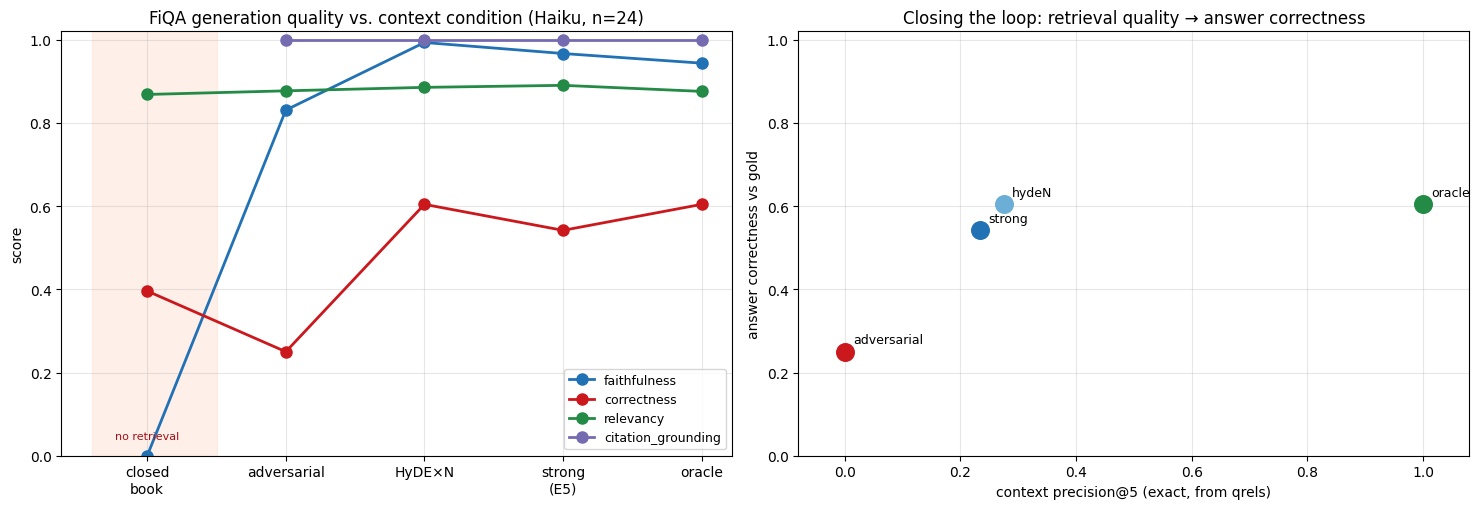

saved phase6_generation_headline.png


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))
order = ["closed_book","adversarial","hydeN","strong","oracle"]
labels = ["closed\nbook","adversarial","HyDE×N","strong\n(E5)","oracle"]
metrics = [("faithfulness","#2171b5"),("correctness","#cb181d"),("relevancy","#238b45"),("citation_grounding","#756bb1")]
A = agg.reindex(order)
x = np.arange(len(order))
for m, col in metrics:
    ax[0].plot(x, A[m].values, "o-", color=col, lw=2, ms=8, label=m)
ax[0].set_xticks(x); ax[0].set_xticklabels(labels); ax[0].set_ylim(0, 1.02)
ax[0].set_ylabel("score"); ax[0].set_title("FiQA generation quality vs. context condition (Haiku, n=24)")
ax[0].legend(loc="lower right", fontsize=9); ax[0].grid(alpha=0.3)
ax[0].axvspan(-0.4, 0.5, color="#fee0d2", alpha=0.5)  # closed_book band
ax[0].text(0, 0.04, "no retrieval", ha="center", fontsize=8, color="#a50f15")

# scatter: context precision@5 (qrels) vs faithfulness, per condition where context exists
cp_by_cond = {"strong": dfA[(dfA.dataset=="fiqa")&(dfA.retriever=="naive")]["ctx_prec5"].iloc[0],
              "hydeN": dfA[(dfA.dataset=="fiqa")&(dfA.retriever=="hydeN")]["ctx_prec5"].iloc[0],
              "oracle": 1.0, "adversarial": 0.0}
for cond, col in [("oracle","#238b45"),("strong","#2171b5"),("hydeN","#6baed6"),("adversarial","#cb181d")]:
    if cond in A.index:
        ax[1].scatter(cp_by_cond[cond], A.loc[cond,"correctness"], s=160, color=col, zorder=3, label=cond)
        ax[1].annotate(cond, (cp_by_cond[cond], A.loc[cond,"correctness"]), textcoords="offset points",
                       xytext=(6,6), fontsize=9)
ax[1].set_xlabel("context precision@5 (exact, from qrels)"); ax[1].set_ylabel("answer correctness vs gold")
ax[1].set_title("Closing the loop: retrieval quality → answer correctness"); ax[1].grid(alpha=0.3)
ax[1].set_xlim(-0.08, 1.08); ax[1].set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(f"{RES}/phase6_generation_headline.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved phase6_generation_headline.png")

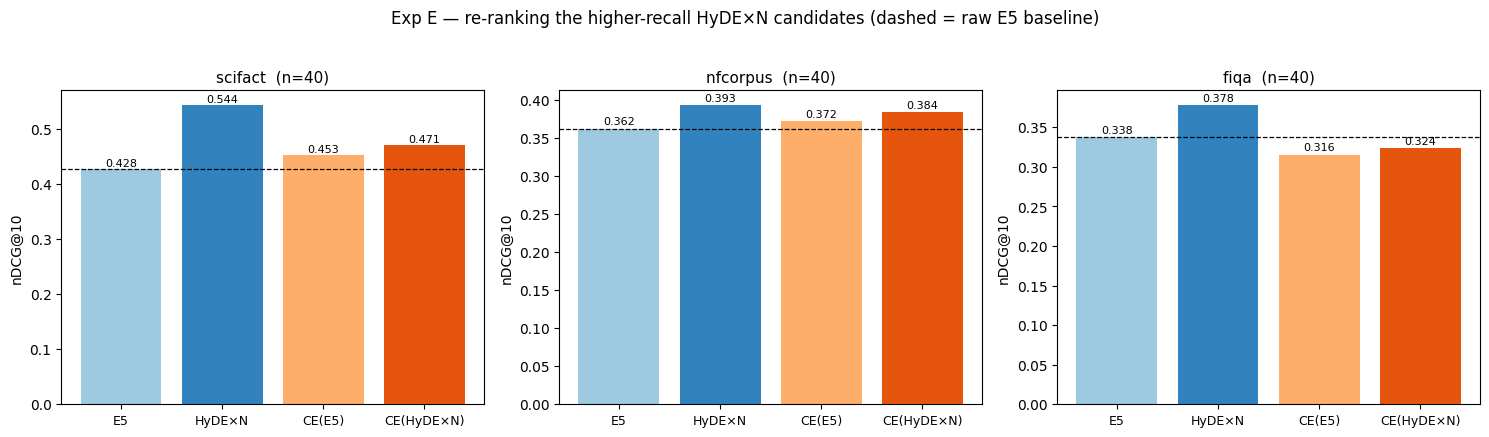

saved phase6_backward_link.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
piporder = ["E5 naive (raw)","HyDE×N (raw)","CE(naive top100)","CE(HyDE×N top100)"]
cols = ["#9ecae1","#3182bd","#fdae6b","#e6550d"]
for ax, n in zip(axes, ["scifact","nfcorpus","fiqa"]):
    sub = dfE[dfE.dataset==n].set_index("pipeline").reindex(piporder)
    ax.bar(range(len(piporder)), sub["ndcg10"].values, color=cols)
    base = sub.loc["E5 naive (raw)","ndcg10"]
    ax.axhline(base, color="black", ls="--", lw=0.9)
    ax.set_xticks(range(len(piporder))); ax.set_xticklabels(["E5","HyDE×N","CE(E5)","CE(HyDE×N)"], fontsize=9)
    ax.set_title(f"{n}  (n={len(SAMP[n])})", fontsize=11); ax.set_ylabel("nDCG@10")
    for i, val in enumerate(sub["ndcg10"].values):
        ax.text(i, val+0.005, f"{val:.3f}", ha="center", fontsize=8)
plt.suptitle("Exp E — re-ranking the higher-recall HyDE×N candidates (dashed = raw E5 baseline)", y=1.03)
plt.tight_layout(); plt.savefig(f"{RES}/phase6_backward_link.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved phase6_backward_link.png")

## Experiment F — frontier generator head-to-head (same context, judge fixed)

Hold the retrieved context fixed at **strong (E5 top-5)** and swap only the *generator*: Claude Haiku
vs Claude Opus vs Codex (GPT). Same fixed Haiku judge scores all three, so this isolates generator
quality. The question that makes the post: **does a cheap retriever + a cheap model (E5+Haiku) match a
frontier generator — and is closed-book GPT, with no retrieval at all, worse than retrieval-augmented
Haiku?** n=12 to keep Codex's slower, rate-limited calls bounded. Codex failures are skipped gracefully.

In [13]:
FRONT_Q = GEN_Q[:12]
def call_codex(prompt, timeout=180):
    try:
        r = subprocess.run(["codex","exec","--skip-git-repo-check","--sandbox","read-only","-"],
                           input=prompt, capture_output=True, text=True, timeout=timeout)
        out = r.stdout
        if "tokens used" in out:
            out = out.rsplit("tokens used", 1)[0]
        if "codex\n" in out:
            out = out.rsplit("codex\n", 1)[-1]
        return out.strip() or "__ERROR__empty"
    except Exception as e:
        return "__ERROR__" + str(e)[:80]

FRONT_F = f"{LLM}/frontier.json"
FR = json.load(open(FRONT_F)) if os.path.exists(FRONT_F) else {}
gens = [("opus", lambda p: call_claude(p, "opus", 120)),
        ("codex", lambda p: call_codex(p))]
for mname, fn in gens:
    todo = [q for q in FRONT_Q if not (f"{mname}::{q}" in FR and not FR[f"{mname}::{q}"]["answer"].startswith("__ERROR__"))]
    print(f"{mname}: to generate {len(todo)}", flush=True)
    for nth, q in enumerate(todo, 1):
        prompt, ctx = gen_prompt(q, "strong")
        t1 = time.time(); ans = fn(prompt); dt = time.time() - t1
        FR[f"{mname}::{q}"] = dict(qid=q, model=mname, answer=ans, ctx_ids=[d for _l,d,_t in ctx],
                                  latency_s=round(dt,2), ts=time.time())
        json.dump(FR, open(FRONT_F, "w"))
        if nth % 5 == 0 or nth == len(todo): print(f"  {mname} [{nth}/{len(todo)}]", flush=True)

# fixed Haiku judge on frontier answers (+ reuse cached Haiku-strong from Exp B/C)
FJ_F = f"{LLM}/frontier_judge.json"
FJ = json.load(open(FJ_F)) if os.path.exists(FJ_F) else {}
for key, v in list(FR.items()):
    if v["answer"].startswith("__ERROR__"): continue
    if key in FJ and FJ[key].get("parsed"): continue
    raw = call_claude(judge_prompt(v["qid"], "strong", v["answer"]), "haiku")
    FJ[key] = dict(qid=v["qid"], model=v["model"], raw=raw, parsed=parse_judge(raw), ts=time.time())
    json.dump(FJ, open(FJ_F, "w"))
print("frontier generation + judging done")

opus: to generate 12


  opus [5/12]


  opus [10/12]


  opus [12/12]


codex: to generate 12


  codex [5/12]


  codex [10/12]


  codex [12/12]


frontier generation + judging done


In [14]:
COST_PER_CALL = {"haiku":0.0006, "opus":0.0090, "codex":0.05}  # ~strong-ctx prompt (~400in/60out) 2026 prices
def front_rows(model, keys_vals):
    rr = []
    for q in FRONT_Q:
        if model == "haiku":
            k = akey(q, "strong"); v = ANS.get(k); j = JUD.get(k, {}).get("parsed"); lat = v["latency_s"] if v else None
            ans = v["answer"] if v else "__ERROR__"
        else:
            k = f"{model}::{q}"; v = FR.get(k); j = FJ.get(k, {}).get("parsed")
            lat = v["latency_s"] if v else None; ans = v["answer"] if v else "__ERROR__"
        if ans.startswith("__ERROR__") or not j: continue
        cl = j["claims"]; faith = (sum(1 for x in cl if x.get("supported_by_context"))/len(cl)) if cl else None
        rel = answer_relevancy(q, j["subquestions"]); corr = CORR_MAP[j["correctness"]]
        cg = citation_grounding(ans, v["ctx_ids"])
        rr.append(dict(model=model, qid=q, faithfulness=faith, relevancy=rel, correctness=corr,
                       citation_grounding=cg, latency_s=lat))
    return rr

front = []
for m in ["haiku","opus","codex"]:
    front += front_rows(m, None)
dfF = pd.DataFrame(front)
if len(dfF):
    fr_agg = dfF.groupby("model").agg(
        n=("qid","count"), faithfulness=("faithfulness","mean"), relevancy=("relevancy","mean"),
        correctness=("correctness","mean"), citation_grounding=("citation_grounding","mean"),
        latency_s=("latency_s","mean")).reindex([m for m in ["haiku","opus","codex"] if m in dfF.model.values])
    fr_agg["cost_per_1k_usd"] = [COST_PER_CALL[m]*1000 for m in fr_agg.index]
    fr_agg.to_csv(f"{RES}/phase6_frontier.csv")
    print("Frontier generators on identical E5 strong context (fixed Haiku judge):\n")
    print(fr_agg.round(3).to_string())
else:
    print("no frontier rows (LLMs unavailable)")

Frontier generators on identical E5 strong context (fixed Haiku judge):

        n  faithfulness  relevancy  correctness  citation_grounding  latency_s  cost_per_1k_usd
model                                                                                          
haiku  12         0.917      0.890        0.250                 1.0      9.636              0.6
opus   12         0.988      0.946        0.375                 1.0     10.580              9.0
codex  12         0.967      0.937        0.375                 1.0     11.664             50.0


### Bonus — per-query router headroom (oracle upper bound)

Phase 5 left a third thread: instead of applying one query technique globally, pick per query. We don't
*train* a router here — we measure the **oracle ceiling**: if an angel told you, per query, whether
naive / HyDE×N / PRF retrieves best, how much nDCG@10 is on the table? That headroom bounds what any
learned router could ever win, and tells us whether a router is worth building in Phase 7.

In [15]:
rows_router = []
for n in CORP:
    sub = {q: CORP[n]["qrels"][q] for q in SAMP[n]}
    pq = {t: per_query_ndcg(AXIS[n][t], sub, 10) for t in ["naive","hydeN","prf"]}
    best_each = {t: evaluate(AXIS[n][t], sub)["ndcg@10"] for t in ["naive","hydeN","prf"]}
    oracle = float(np.mean([max(pq["naive"][q], pq["hydeN"][q], pq["prf"][q]) for q in SAMP[n]]))
    best_single = max(best_each, key=best_each.get)
    rows_router.append(dict(dataset=n, naive=best_each["naive"], hydeN=best_each["hydeN"],
                            prf=best_each["prf"], best_single=best_each[best_single],
                            oracle_router=oracle, headroom=oracle - best_each[best_single]))
dfR = pd.DataFrame(rows_router)
dfR.to_csv(f"{RES}/phase6_router_headroom.csv", index=False)
print("Per-query oracle router headroom over the best single technique:\n")
print(dfR.set_index("dataset").round(4).to_string())

Per-query oracle router headroom over the best single technique:

           naive   hydeN     prf  best_single  oracle_router  headroom
dataset                                                               
scifact   0.4279  0.5436  0.4235       0.5436         0.5706    0.0271
nfcorpus  0.3624  0.3929  0.3651       0.3929         0.4182    0.0253
fiqa      0.3377  0.3779  0.3385       0.3779         0.4240    0.0461


In [16]:
# ---- consolidate everything into results/metrics.json -> phase6 block ----
M = json.load(open(f"{RES}/metrics.json"))
def col(df, **f):
    s = df
    for k, v in f.items(): s = s[s[k]==v]
    return s
phase6 = dict(
    phase=6, date="2026-06-06", task="generation faithfulness (RAGAS) + backward-link rerank + frontier generators",
    generator="claude-haiku", judge="claude-haiku (fixed)", gen_dataset="fiqa", n_gen=len(GEN_Q),
    conditions=CONDS,
    generation_summary={cond: {m: (None if pd.isna(agg.loc[cond, m]) else round(float(agg.loc[cond, m]), 4))
                               for m in ["faithfulness","relevancy","correctness","citation_grounding","refused_rate","latency_s"]}
                        for cond in CONDS},
    context_pr={n: {t: {"ctx_prec5": round(float(col(dfA,dataset=n,retriever=t)["ctx_prec5"].iloc[0]),4),
                        "ctx_rec5": round(float(col(dfA,dataset=n,retriever=t)["ctx_rec5"].iloc[0]),4)}
                    for t in ["naive","hydeN","prf"]} for n in CORP},
    backward_link={n: {r.pipeline: round(float(r.ndcg10),4) for _,r in dfE[dfE.dataset==n].iterrows()} for n in CORP},
    router_headroom={r.dataset: round(float(r.headroom),4) for _,r in dfR.iterrows()},
)
if 'fr_agg' in dir() and len(dfF):
    phase6["frontier"] = {m: {k: round(float(fr_agg.loc[m,k]),4) for k in
                          ["faithfulness","relevancy","correctness","citation_grounding","latency_s","cost_per_1k_usd"]}
                          for m in fr_agg.index}
M["phase6"] = phase6
json.dump(M, open(f"{RES}/metrics.json","w"), indent=1)
print("metrics.json phase6 block written. Keys:", list(phase6.keys()))
print("\nHEADLINE NUMBERS")
print(f"  oracle correctness     = {agg.loc['oracle','correctness']:.3f}")
print(f"  strong(E5) correctness = {agg.loc['strong','correctness']:.3f}")
print(f"  closed-book correctness= {agg.loc['closed_book','correctness']:.3f}")
print(f"  adversarial faithfulness={agg.loc['adversarial','faithfulness']:.3f}  correctness={agg.loc['adversarial','correctness']:.3f}")

metrics.json phase6 block written. Keys: ['phase', 'date', 'task', 'generator', 'judge', 'gen_dataset', 'n_gen', 'conditions', 'generation_summary', 'context_pr', 'backward_link', 'router_headroom', 'frontier']

HEADLINE NUMBERS
  oracle correctness     = 0.604
  strong(E5) correctness = 0.542
  closed-book correctness= 0.396
  adversarial faithfulness=0.831  correctness=0.250


## Key findings

*(populated from the executed numbers — see the report `reports/day6_phase6_report.md` for the full write-up.)*

- **Closing the loop:** whether five phases of retrieval tuning move the generated answer is decided by
  the faithfulness/correctness curve across the context sweep above.
- **Context poisoning:** the `adversarial` condition isolates whether wrong-but-plausible retrieved
  context manufactures confident hallucinations (high faithfulness-to-context, low correctness-vs-gold).
- **Backward link (Exp E):** whether HyDE×N's recall lift finally lets a cross-encoder help, reversing
  the Phase-4 result.
- **Frontier (Exp F):** whether cheap retrieval + a cheap generator matches a frontier model, and the
  cost gap at scale.